## Notebook: Financial Analytics
*PADS - Programa Avançado em Data Science*

Insper

**Paloma Vaissman Uribe**

### We will start by picking up some data from Yahoo Finance APIs

In [4]:
import yfinance as yf

#getting historic stock data from yfinance
stocks_list = ['BBDC4.SA', 'ITUB4.SA','SANB4.SA', 'BBAS3.SA']
data = yf.download(stocks_list, period='5y')['Close']
data

/tmp/ipython-input-1513362024.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks_list, period='5y')['Close']
[*********************100%***********************]  4 of 4 completed


Ticker,BBAS3.SA,BBDC4.SA,ITUB4.SA,SANB4.SA
Date,,,,
2020-11-23,11.589112,14.348302,20.156155,14.215531
2020-11-24,11.897979,14.993038,20.721098,14.784431
2020-11-25,11.864407,14.799619,20.476992,15.099722
2020-11-26,11.676399,14.559301,20.044575,15.264223
2020-11-27,11.619331,14.442083,20.198011,15.181969
...,...,...,...,...
2025-11-14,22.440001,19.469999,40.599998,17.500000
2025-11-17,22.500000,19.320000,40.299999,17.270000
2025-11-18,21.879999,19.090000,40.099998,17.330000


### Then we transform data to build log returns:

In [5]:
# function to build log returns from a dataframe
def log_returns(df):
  import numpy as np
  df_ = df.copy()
  for stock in df.columns:
      df_[stock] = np.log(df_[stock]).diff()
  return df_.dropna()

In [6]:
# applying the function
daily_returns = log_returns(data)
daily_returns

Ticker,BBAS3.SA,BBDC4.SA,ITUB4.SA,SANB4.SA
Date,,,,
2020-11-24,0.026302,0.043954,0.027643,0.039240
2020-11-25,-0.002826,-0.012985,-0.011851,0.021102
2020-11-26,-0.015973,-0.016371,-0.021343,0.010835
2020-11-27,-0.004899,-0.008084,0.007626,-0.005403
2020-11-30,-0.021908,-0.013895,-0.013909,-0.050462
...,...,...,...,...
2025-11-14,-0.002670,-0.000513,0.003949,0.014969
2025-11-17,0.002670,-0.007734,-0.007417,-0.013230
2025-11-18,-0.027942,-0.011976,-0.004975,0.003468


### Then we can plot log returns and understand about conditional hererocedasticy and distribution

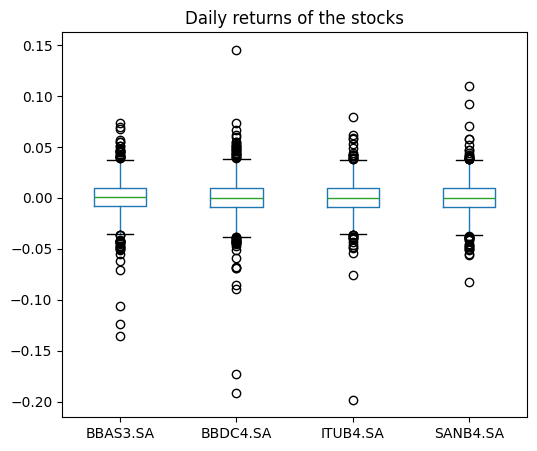

In [7]:
import matplotlib.pyplot as plt

# Boxplot of daily returns
daily_returns.boxplot(figsize=(6, 5), grid=False)
plt.title("Daily returns of the stocks");

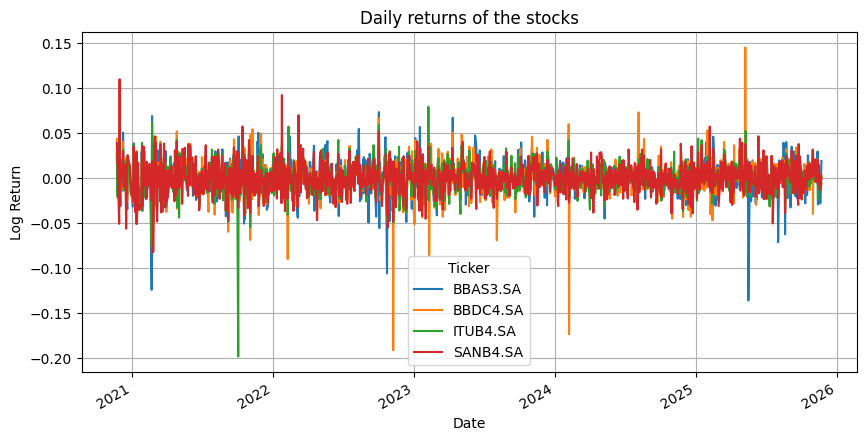

In [8]:
# Lineplot of daily returns
daily_returns.plot(figsize=(10, 5))
plt.title("Daily returns of the stocks")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show();

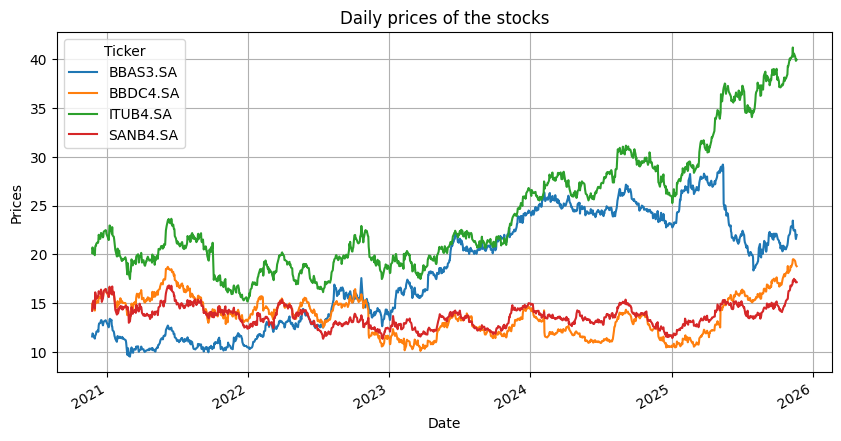

In [9]:
# Lineplot of prices
data.plot(figsize=(10, 5))
plt.title("Daily prices of the stocks")
plt.xlabel("Date")
plt.ylabel("Prices")
plt.grid(True)
plt.show();

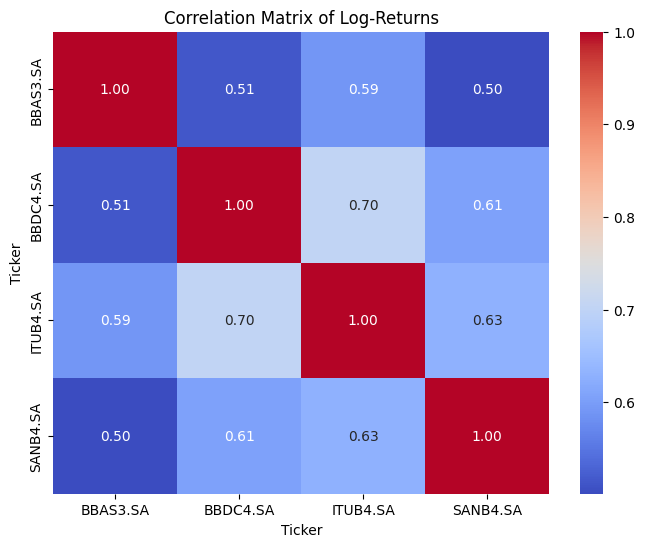

In [10]:
# matrix correlation of log-returns

import seaborn as sns
correlation_matrix = daily_returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Log-Returns')
plt.show()

In [11]:
# calculate historical volatility of log_returns (generated by AI)

def historical_volatility(log_returns, annualizing_factor=252):
  """Calculates the historical volatility of log returns.

  Args:
    log_returns: A pandas DataFrame of daily log returns.
    annualizing_factor: The number of trading days in a year (default is 252).

  Returns:
    A pandas Series of annualized historical volatility for each asset.
  """
  import numpy as np
  import pandas as pd

  daily_volatility = log_returns.std()
  annualized_volatility = daily_volatility * np.sqrt(annualizing_factor)
  return annualized_volatility

# Calculate historical volatility for the daily returns
historical_vol = historical_volatility(daily_returns)
print("\nHistorical Volatility:")
historical_vol


Historical Volatility:


,0
Ticker,
BBAS3.SA,0.275599
BBDC4.SA,0.303753
ITUB4.SA,0.257582
SANB4.SA,0.269779


### Now let's calculate CAPM model for the assets. For this we need to pick up the market return

In [12]:
#getting historic stock data from yfinance
stocks_list = ['^BVSP']
ibov = yf.download(stocks_list, period='5y')['Close']
mkt_returns = log_returns(ibov)
mkt_returns = mkt_returns.rename(columns={'^BVSP': 'mkt_return'})

/tmp/ipython-input-684809409.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download(stocks_list, period='5y')['Close']
[*********************100%***********************]  1 of 1 completed


In [13]:
mkt_returns

Ticker,mkt_return
Date,
2020-11-24,0.022168
2020-11-25,0.003156
2020-11-26,0.000853
2020-11-27,0.003152
2020-11-30,-0.015374
...,...
2025-11-14,0.003665
2025-11-17,-0.004741
2025-11-18,-0.003005


In [14]:
# prompt: capm model between log_returns and mkt_returns

import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


beta_sm, alpha_sm = dict(), dict()

# Loop through each stock to perform regression
for stock in daily_returns.columns:

  # Define dependent and independent variables
  y = daily_returns[stock]
  X = mkt_returns['mkt_return']

  # Add a constant for the intercept (alpha)
  X = sm.add_constant(X)

  # Perform the regression
  model = sm.OLS(y, X).fit()

  # Extract beta and alpha
  beta_sm[stock] = model.params['mkt_return']
  alpha_sm[stock] = model.params['const']

  # Print the regression results summary
  print(f"\nCAPM Regression Results for {stock}:")
  print(model.summary())

print("\nBetas from statsmodels:")
print(beta_sm)

print("\nAlphas from statsmodels:")
print(alpha_sm)


CAPM Regression Results for BBAS3.SA:
                            OLS Regression Results                            
Dep. Variable:               BBAS3.SA   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     815.1
Date:                Mon, 24 Nov 2025   Prob (F-statistic):          2.70e-138
Time:                        00:38:31   Log-Likelihood:                 3597.1
No. Observations:                1246   AIC:                            -7190.
Df Residuals:                    1244   BIC:                            -7180.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

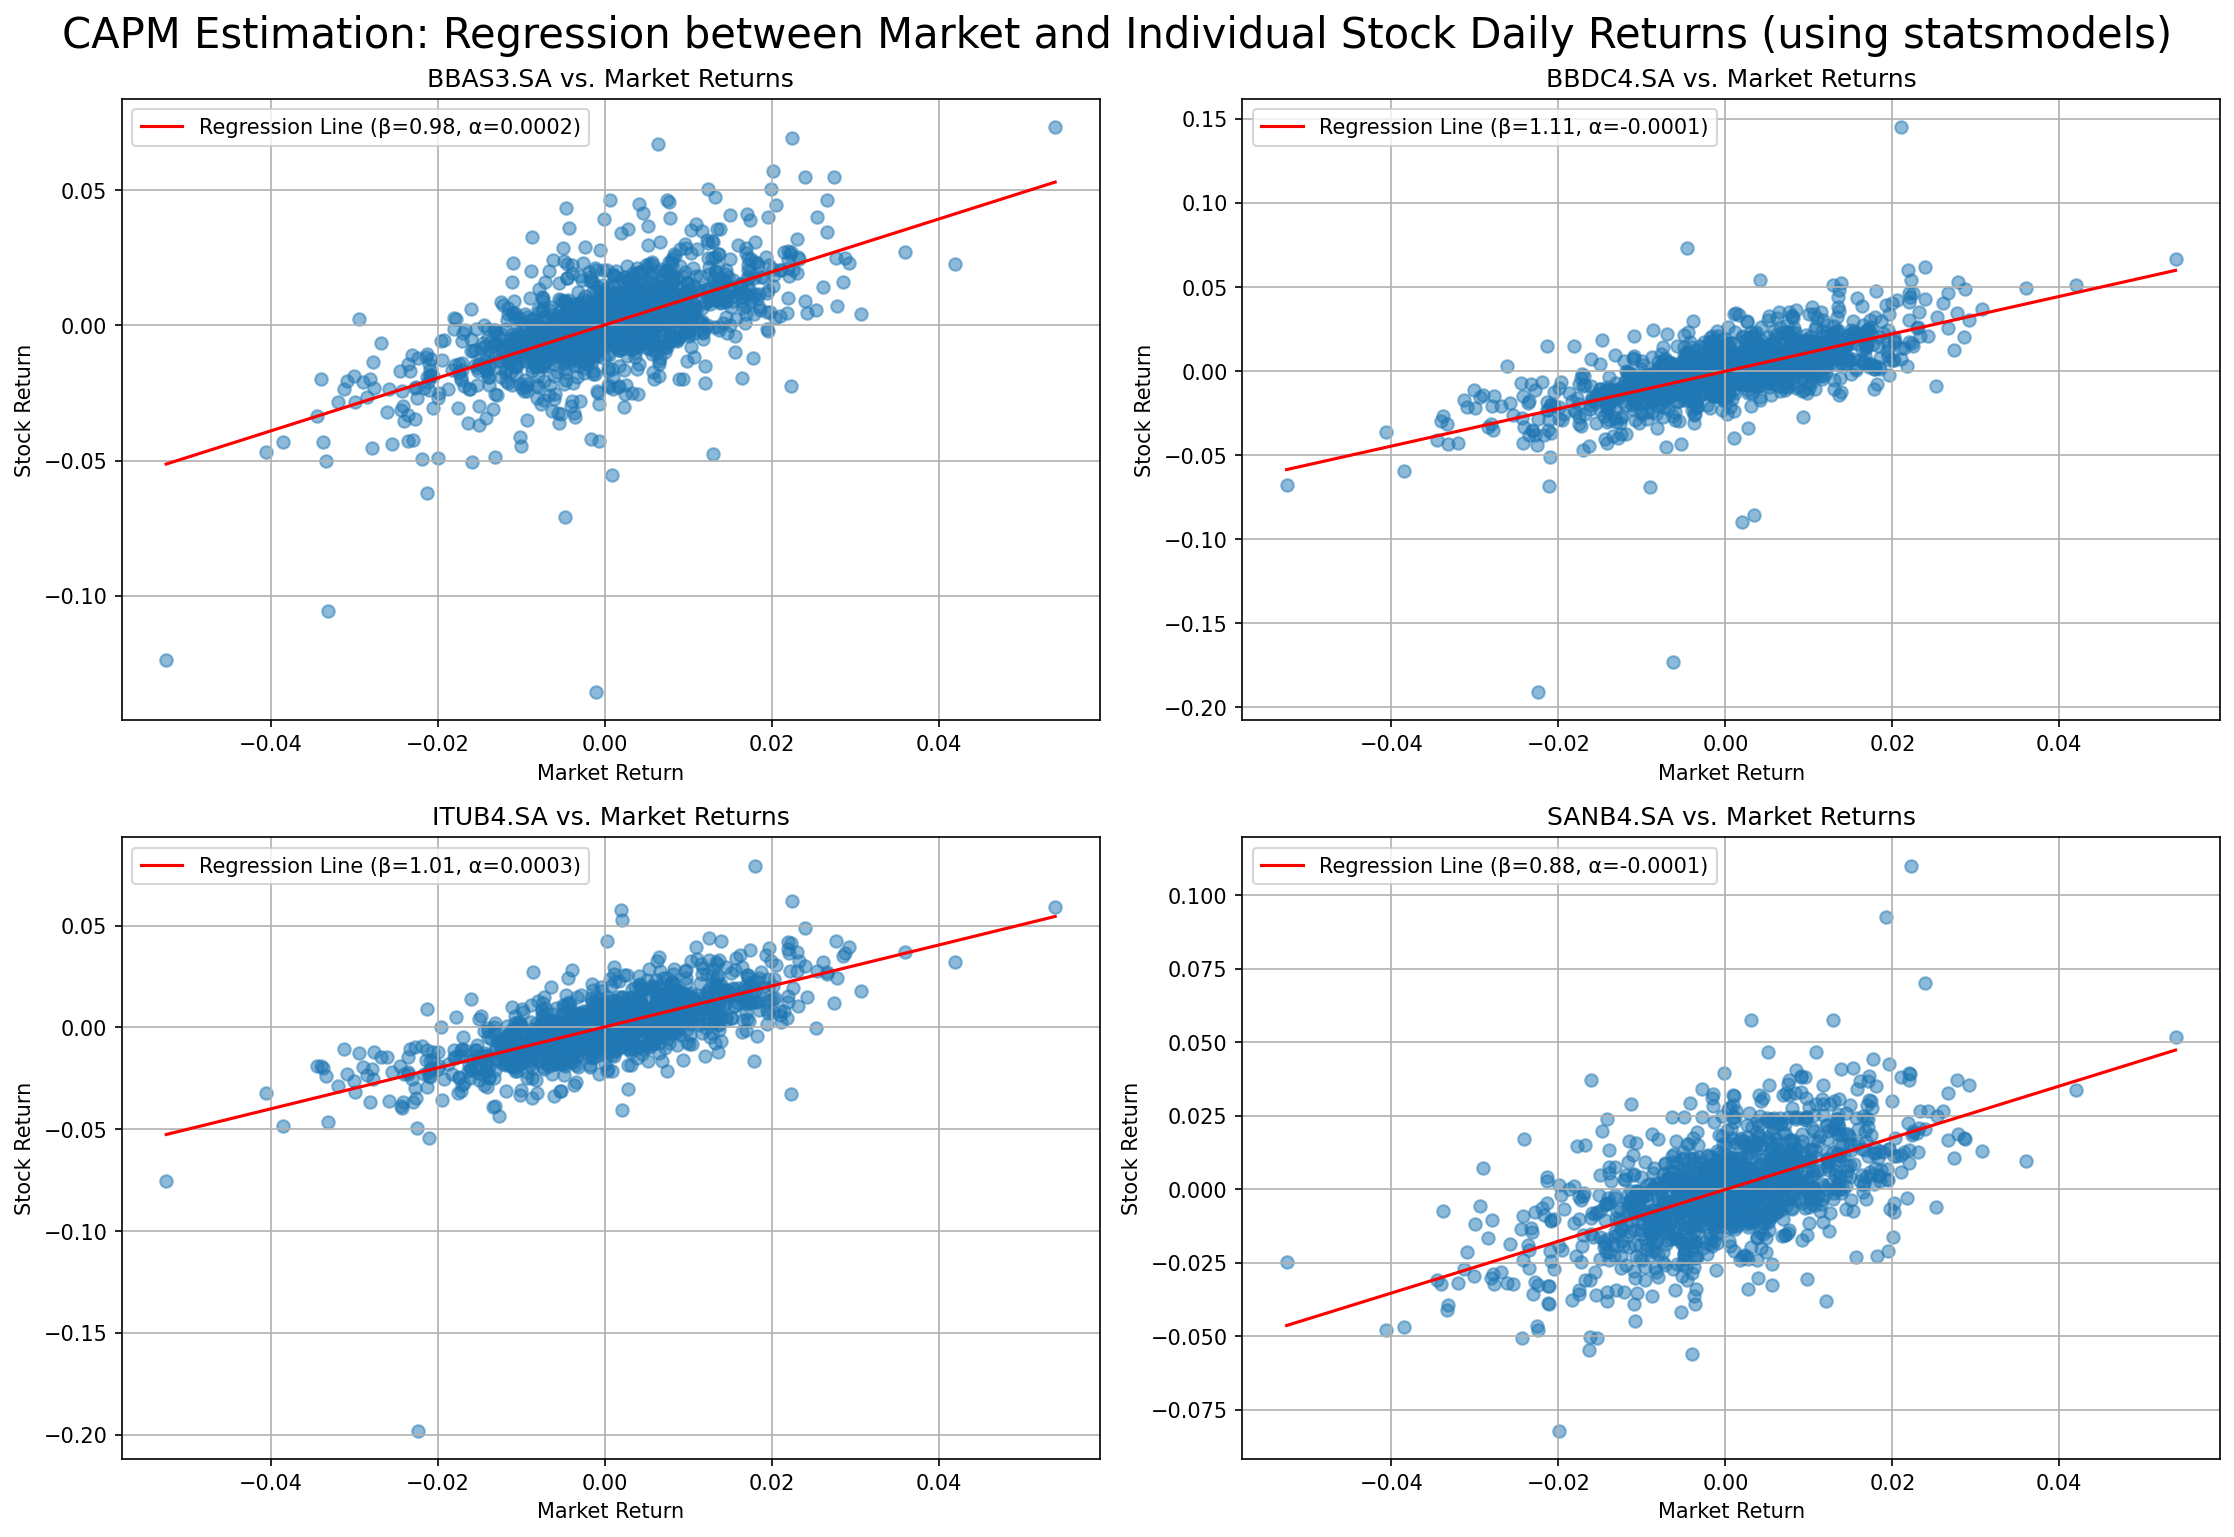

In [15]:
# Plotting the regressions using statsmodels
fig, axes = plt.subplots(2, 2, dpi=150, figsize=(15, 10))
axes = axes.flatten()

for stock in daily_returns.columns:
    idx = daily_returns.columns.get_loc(stock)

    if stock in beta_sm and stock in alpha_sm:
        X = mkt_returns['mkt_return']
        y = daily_returns[stock]

        # Scatter plot
        axes[idx].scatter(X, y, alpha=0.5)

        # Add the regression line using the statsmodels results
        # Create a range of market return values for the line
        mkt_return_range = np.linspace(X.min(), X.max(), 100)
        regression_line = alpha_sm[stock] + beta_sm[stock] * mkt_return_range

        axes[idx].plot(mkt_return_range, regression_line, color='red', label=f'Regression Line (β={beta_sm[stock]:.2f}, α={alpha_sm[stock]:.4f})')

        axes[idx].set_title(f'{stock} vs. Market Returns')
        axes[idx].set_xlabel('Market Return')
        axes[idx].set_ylabel('Stock Return')
        axes[idx].legend()
        axes[idx].grid(True)
    else:
        axes[idx].set_title(f'{stock} vs. Market Returns - Data Missing')
        axes[idx].text(0.5, 0.5, 'Data Missing', horizontalalignment='center', verticalalignment='center', transform=axes[idx].transAxes)


plt.tight_layout()
plt.suptitle("CAPM Estimation: Regression between Market and Individual Stock Daily Returns (using statsmodels)", size=20, y=1.02)
plt.show()


Rolling Betas:
Ticker      BBAS3.SA  BBDC4.SA  ITUB4.SA  SANB4.SA
Date                                              
2025-11-14  0.930405  1.351129  1.064526  1.089529
2025-11-17  0.929828  1.350274  1.064493  1.090589
2025-11-18  0.927886  1.350379  1.064119  1.091876
2025-11-19  0.931838  1.351916  1.064345  1.090772
2025-11-21  0.933553  1.352218  1.063913  1.091879


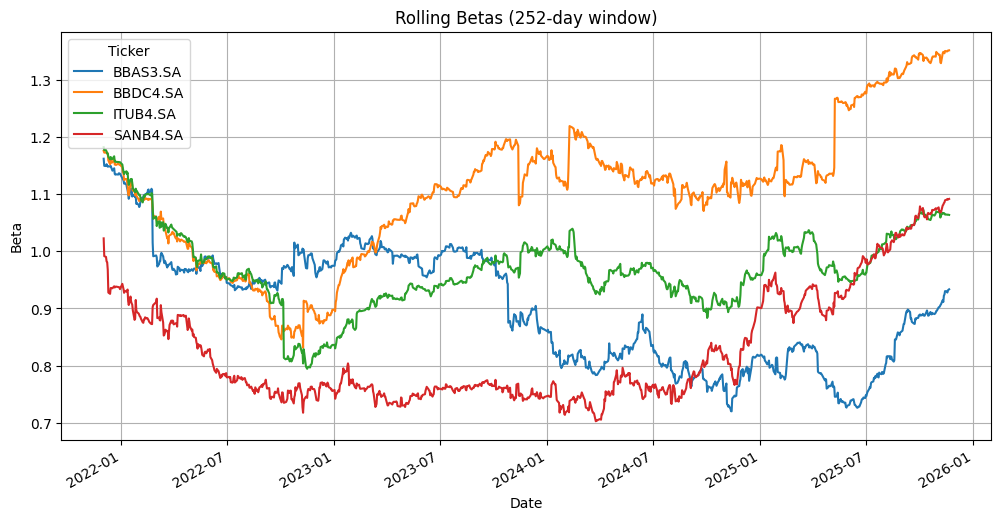

In [16]:
# prompt: rolling betas camp for daily_returns using statsmodels regression

def rolling_betas_camp(daily_returns, mkt_returns, window):
    """
    Calculates rolling betas for a list of stocks against the market using statsmodels OLS.

    Args:
        daily_returns (pd.DataFrame): DataFrame of daily log returns for the stocks.
        mkt_returns (pd.DataFrame): DataFrame of daily log returns for the market.
        window (int): The size of the rolling window.

    Returns:
        pd.DataFrame: DataFrame containing the rolling betas for each stock.
    """
    rolling_betas = pd.DataFrame(index=daily_returns.index, columns=daily_returns.columns)

    for stock in daily_returns.columns:
        for i in range(window, len(daily_returns)):
            # Define the rolling window
            window_returns = daily_returns[stock].iloc[i-window:i]
            window_mkt_returns = mkt_returns['mkt_return'].iloc[i-window:i]

            # Ensure there are enough data points in the window
            if len(window_returns) == window and len(window_mkt_returns) == window:
                # Define dependent and independent variables
                y = window_returns
                X = window_mkt_returns

                # Add a constant for the intercept (alpha)
                X = sm.add_constant(X)

                # Perform the regression
                try:
                    model = sm.OLS(y, X).fit()
                    # Store the beta value
                    rolling_betas.loc[daily_returns.index[i], stock] = model.params['mkt_return']
                except Exception as e:
                    # Handle cases where regression might fail (e.g., no variation in data)
                    print(f"Regression failed for {stock} at index {daily_returns.index[i]}: {e}")
                    rolling_betas.loc[daily_returns.index[i], stock] = np.nan

    return rolling_betas

# Calculate rolling betas with a window of 252 trading days (approx 1 year)
rolling_betas = rolling_betas_camp(daily_returns, mkt_returns, window=252)

print("\nRolling Betas:")
print(rolling_betas.tail())

# Plot the rolling betas
rolling_betas.plot(figsize=(12, 6))
plt.title('Rolling Betas (252-day window)')
plt.xlabel('Date')
plt.ylabel('Beta')
plt.grid(True)
plt.show()

### Comparing expected return of stock prices with actual historical returns

In [46]:
daily_returns_level = np.exp(daily_returns)-1
daily_returns_level

Ticker,BBAS3.SA,BBDC4.SA,ITUB4.SA,SANB4.SA
Date,,,,
2020-11-24,0.026651,0.044935,0.028028,0.040020
2020-11-25,-0.002822,-0.012901,-0.011781,0.021326
2020-11-26,-0.015846,-0.016238,-0.021117,0.010894
2020-11-27,-0.004887,-0.008051,0.007655,-0.005389
2020-11-30,-0.021670,-0.013799,-0.013812,-0.049209
...,...,...,...,...
2025-11-14,-0.002667,-0.000513,0.003956,0.015081
2025-11-17,0.002674,-0.007704,-0.007389,-0.013143
2025-11-18,-0.027556,-0.011905,-0.004963,0.003474


In [53]:
def calculate_cumulative_returns(returns):
    """
    Calculates cumulative returns from a series of simple returns.

    Args:
      returns: A pandas Series or NumPy array of simple returns.

    Returns:
      A pandas Series or NumPy array of cumulative returns.
    """
    cumulative_returns = (1 + daily_returns_level).cumprod() - 1
    return cumulative_returns

# Example usage:
# Assuming you have a pandas Series of daily returns called 'daily_returns'
# Example Data

cumulative_returns = calculate_cumulative_returns(returns)

print(cumulative_returns)

Ticker      BBAS3.SA  BBDC4.SA  ITUB4.SA  SANB4.SA
Date                                              
2020-11-24  0.026651  0.044935  0.028028  0.040020
2020-11-25  0.023755  0.031454  0.015918  0.062199
2020-11-26  0.007532  0.014706 -0.005536  0.073771
2020-11-27  0.002608  0.006536  0.002077  0.067985
2020-11-30 -0.019119 -0.007353 -0.011764  0.015430
...              ...       ...       ...       ...
2025-11-14  0.936300  0.356955  1.014273  0.231048
2025-11-17  0.941477  0.346501  0.999389  0.214868
2025-11-18  0.887979  0.330471  0.989467  0.219089
2025-11-19  0.862093  0.317229  0.977064  0.205020
2025-11-21  0.898333  0.309563  0.983017  0.206427

[1246 rows x 4 columns]


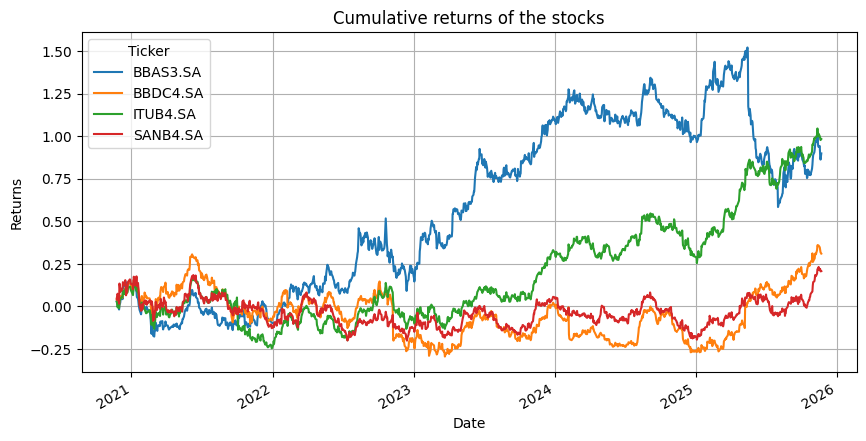

In [48]:
# Lineplot of daily returns
cumulative_returns.plot(figsize=(10, 5))
plt.title("Cumulative returns of the stocks")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.grid(True)
plt.show();

In [49]:
np.exp(mkt_returns)-1

Ticker,mkt_return
Date,
2020-11-24,0.022416
2020-11-25,0.003161
2020-11-26,0.000854
2020-11-27,0.003157
2020-11-30,-0.015257
...,...
2025-11-14,0.003671
2025-11-17,-0.004729
2025-11-18,-0.003000


In [50]:
mkt_returns

Ticker,mkt_return
Date,
2020-11-24,0.022168
2020-11-25,0.003156
2020-11-26,0.000853
2020-11-27,0.003152
2020-11-30,-0.015374
...,...
2025-11-14,0.003665
2025-11-17,-0.004741
2025-11-18,-0.003005


In [52]:
# Estimate the expected return of the market using the daily returns

ER = dict()

rf = 0.1383

#mkt_returns_level = np.exp(mkt_returns)-1
rm = mkt_returns.mean()*252

for k in daily_returns.columns:

    # Calculate return for every security using CAPM

    ER[k] = rf + beta_sm[k] * (rm-rf)

    print("Expected return based on CAPM model for {} is {}%".format(k, round(ER[k]*100, 2)))

    # Calculating historic returns

    print('Return based on historical data for {} is {}%'.format(k, round(daily_returns[k].mean() * 100 * 252, 2)))

Expected return based on CAPM model for BBAS3.SA is Ticker
mkt_return    7.52
dtype: float64%
Return based on historical data for BBAS3.SA is 12.96%
Expected return based on CAPM model for BBDC4.SA is Ticker
mkt_return    6.67
dtype: float64%
Return based on historical data for BBDC4.SA is 5.45%
Expected return based on CAPM model for ITUB4.SA is Ticker
mkt_return    7.36
dtype: float64%
Return based on historical data for ITUB4.SA is 13.85%
Expected return based on CAPM model for SANB4.SA is Ticker
mkt_return    8.17
dtype: float64%
Return based on historical data for SANB4.SA is 3.8%


In [20]:
rm

np.float64(0.07393662034276567)

In [54]:
# prompt: calculate sharpe ratio of daily_returns

def sharpe_ratio(returns, risk_free_rate=0):
    """
    Calculates the Sharpe Ratio for a given series of returns.

    Args:
        returns (pd.Series or np.array): A series or array of returns.
        risk_free_rate (float): The risk-free rate of return (default is 0).
                                Should be on the same frequency as the returns.

    Returns:
        float: The Sharpe Ratio.
    """
    excess_returns = returns - risk_free_rate
    return excess_returns.mean() / excess_returns.std()

# Calculate Sharpe Ratio for each stock
sharpe_ratios = {}
annualized_risk_free_rate = rf # Using the already defined annualized risk-free rate

# Assuming the risk-free rate is given as an annual rate, we need to convert it
# to the same frequency as the daily returns. For daily returns, we take the
# daily equivalent risk-free rate.
# daily_risk_free_rate = (1 + annualized_risk_free_rate)**(1/252) - 1
# A simpler approximation is annual_rate / 252 for small rates.
# Let's use the approximation for simplicity here, assuming rf is an annualized rate.
daily_risk_free_rate = annualized_risk_free_rate / 252

for stock in daily_returns.columns:
    sharpe_ratios[stock] = sharpe_ratio(daily_returns[stock], daily_risk_free_rate)

print("\nSharpe Ratios:")
for stock, ratio in sharpe_ratios.items():
    print(f"{stock}: {ratio:.4f}")


Sharpe Ratios:
BBAS3.SA: -0.0020
BBDC4.SA: -0.0174
ITUB4.SA: 0.0000
SANB4.SA: -0.0234


Iteration:      5,   Func. Count:     39,   Neg. LLF: -3154.1819099755176
Iteration:     10,   Func. Count:     67,   Neg. LLF: -3188.1621902352554
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3188.16219023508
            Iterations: 10
            Function evaluations: 67
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results                      
Dep. Variable:               BBDC4.SA   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3188.16
Distribution:                  Normal   AIC:                          -6368.32
Method:            Maximum Likelihood   BIC:                          -6347.81
                                        No. Observations:                 1246
Date:                Mon, Nov 24 2025   Df Residuals:                     1245
Time:      

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003658. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


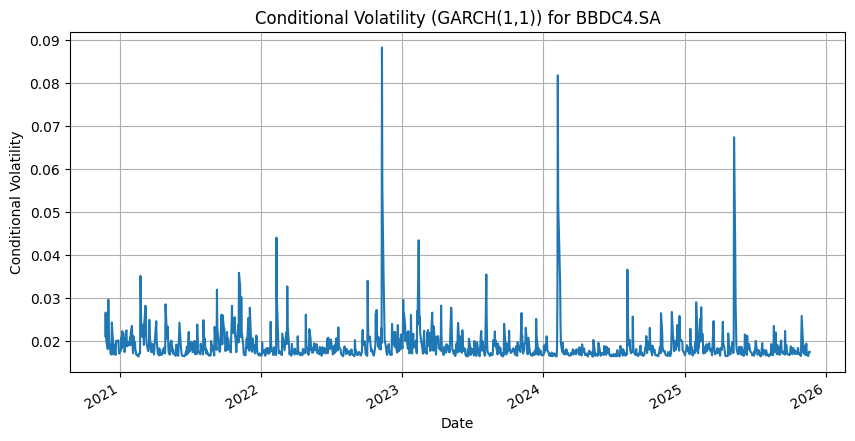


GARCH(1,1) Volatility Forecast for BBDC4.SA (next 5 days):
            Forecasted Volatility
2025-11-22               0.017006
2025-11-23               0.018269
2025-11-24               0.018931
2025-11-25               0.019287
2025-11-26               0.019481


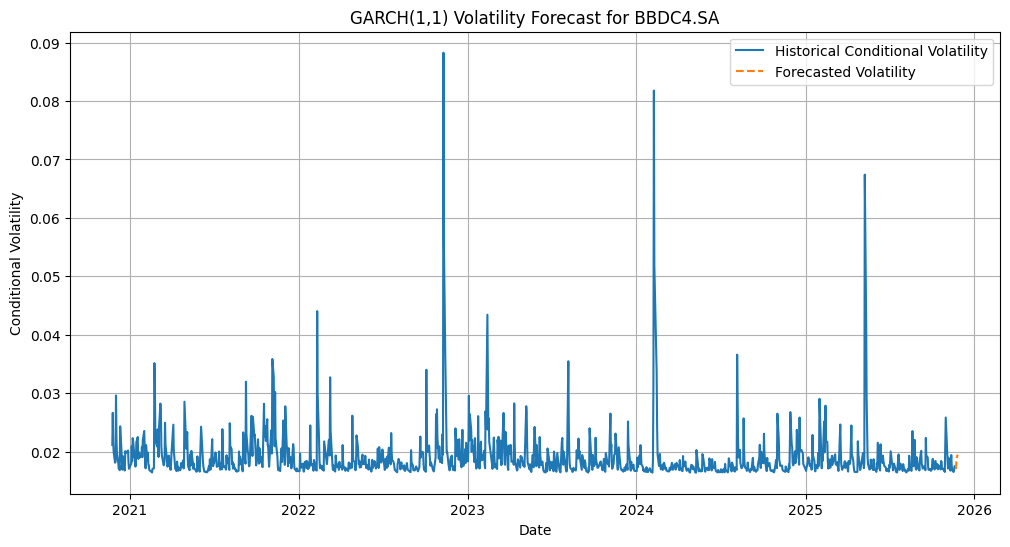

In [55]:
# prompt: Garch model volatility forecast for daily_returns

!pip install arch
from arch import arch_model

# Select one stock to model (e.g., BBDC4.SA)
stock_to_model = 'BBDC4.SA'
returns_to_model = daily_returns[stock_to_model]

# Fit a GARCH(1, 1) model
# The `vol='GARCH'` specifies the GARCH process
# The `p=1` and `q=1` specify the orders of the AR and MA terms for the variance equation
am = arch_model(returns_to_model, vol='Garch', p=1, q=1)
res = am.fit(update_freq=5)

# Print the model summary
print(res.summary())

# Plot the conditional variance (volatility)
fig = res.conditional_volatility.plot(figsize=(10, 5))
plt.title(f'Conditional Volatility (GARCH(1,1)) for {stock_to_model}')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.grid(True)
plt.show()

# Make a forecast of the conditional volatility
# Forecast for the next 5 days
forecast_horizon = 5
forecasts = res.forecast(horizon=forecast_horizon)

# The forecast object contains different types of forecasts.
# We are interested in the volatility forecasts.
# 'h.0' is the mean of the conditional variance forecast
# 'h.1' are the quantiles (if calculated)
# 'variance' is the forecast of the conditional variance itself
# We need to take the square root of the variance forecast to get volatility
forecast_volatility = np.sqrt(forecasts.variance)

# The forecast is given for the horizons starting from the last observation.
# Get the index for the forecast
last_date = returns_to_model.index[-1]
forecast_dates = pd.date_range(start=last_date, periods=forecast_horizon + 1, freq='D')[1:] # +1 and [1:] to exclude the last historical date

print(f'\nGARCH(1,1) Volatility Forecast for {stock_to_model} (next {forecast_horizon} days):')
forecast_df = pd.DataFrame(forecast_volatility.iloc[-1].values, index=forecast_dates, columns=['Forecasted Volatility'])
print(forecast_df)

# Optional: Plot the historical conditional volatility and the forecast
plt.figure(figsize=(12, 6))
plt.plot(res.conditional_volatility.index, res.conditional_volatility, label='Historical Conditional Volatility')
plt.plot(forecast_df.index, forecast_df['Forecasted Volatility'], label='Forecasted Volatility', linestyle='--')
plt.title(f'GARCH(1,1) Volatility Forecast for {stock_to_model}')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
daily_returns.std()

,0
Ticker,
BBAS3.SA,0.017361
BBDC4.SA,0.019135
ITUB4.SA,0.016226
SANB4.SA,0.016994


In [24]:
# prompt: value at risk for daily_returns using volatility models

def calculate_value_at_risk(returns, confidence_level=0.95, model='historical', volatility_model=None):
    """
    Calculates Value at Risk (VaR) for a series of returns.

    Args:
        returns (pd.Series): A series of returns.
        confidence_level (float): The confidence level for the VaR (e.g., 0.95 for 95%).
        model (str): The VaR model to use. Options: 'historical', 'parametric' (uses normal distribution), 'parametric_garch'.
        volatility_model: Fitted volatility model object (e.g., from `arch_model.fit()`) if model is 'parametric_garch'.

    Returns:
        float: The calculated VaR.
    """
    alpha = 1 - confidence_level

    if model == 'historical':
        # Historical VaR: VaR is the quantile of historical returns
        VaR = -np.percentile(returns, alpha * 100)

    elif model == 'parametric':
        # Parametric VaR (Normal Distribution): VaR = - (mean + Z * std_dev)
        # Assuming mean is close to zero for daily returns, VaR approx -Z * std_dev
        # Z is the z-score corresponding to the confidence level
        from scipy.stats import norm
        mean_return = returns.mean()
        std_dev_return = returns.std()
        z_score = norm.ppf(alpha)
        VaR = -(mean_return + z_score * std_dev_return)

    elif model == 'parametric_garch' and volatility_model is not None:
        # Parametric VaR (using GARCH forecasted volatility)
        from scipy.stats import norm
        # Get the last conditional volatility from the GARCH model
        # This assumes you are calculating VaR for the next period based on the model
        forecasted_volatility = volatility_model.conditional_volatility.iloc[-1]
        mean_return = returns.mean() # You could potentially use forecasted mean if your model predicts it
        z_score = norm.ppf(alpha)
        VaR = -(mean_return + z_score * forecasted_volatility)

    else:
        raise ValueError("Invalid VaR model specified or missing volatility_model for 'parametric_garch'.")

    return VaR

# --- Calculate VaR using different models ---

# Select the stock for VaR calculation
stock_for_var = 'BBDC4.SA'
returns_for_var = daily_returns[stock_for_var]

# 1. Historical VaR (e.g., 95% confidence)
var_historical_95 = calculate_value_at_risk(returns_for_var, confidence_level=0.95, model='historical')
print(f"\nHistorical VaR (95%) for {stock_for_var}: {var_historical_95:.4f}")

var_historical_99 = calculate_value_at_risk(returns_for_var, confidence_level=0.99, model='historical')
print(f"Historical VaR (99%) for {stock_for_var}: {var_historical_99:.4f}")


# 2. Parametric VaR (Normal Distribution)
var_parametric_95 = calculate_value_at_risk(returns_for_var, confidence_level=0.95, model='parametric')
print(f"\nParametric VaR (Normal, 95%) for {stock_for_var}: {var_parametric_95:.4f}")

var_parametric_99 = calculate_value_at_risk(returns_for_var, confidence_level=0.99, model='parametric')
print(f"Parametric VaR (Normal, 99%) for {stock_for_var}: {var_parametric_99:.4f}")


# 3. Parametric VaR (using GARCH(1,1) volatility)
# We need the fitted GARCH model object ('res' from the previous cell)
if 'res' in globals(): # Check if the 'res' object exists
  var_parametric_garch_95 = calculate_value_at_risk(returns_for_var, confidence_level=0.95, model='parametric_garch', volatility_model=res)
  print(f"\nParametric VaR (GARCH(1,1) Volatility, 95%) for {stock_for_var}: {var_parametric_garch_95:.4f}")

  var_parametric_garch_99 = calculate_value_at_risk(returns_for_var, confidence_level=0.99, model='parametric_garch', volatility_model=res)
  print(f"Parametric VaR (GARCH(1,1) Volatility, 99%) for {stock_for_var}: {var_parametric_garch_99:.4f}")
else:
  print("\nSkipping GARCH-based VaR calculation as the GARCH model ('res') is not fitted in this session.")




Historical VaR (95%) for BBDC4.SA: 0.0273
Historical VaR (99%) for BBDC4.SA: 0.0437

Parametric VaR (Normal, 95%) for BBDC4.SA: 0.0313
Parametric VaR (Normal, 99%) for BBDC4.SA: 0.0443

Parametric VaR (GARCH(1,1) Volatility, 95%) for BBDC4.SA: 0.0285
Parametric VaR (GARCH(1,1) Volatility, 99%) for BBDC4.SA: 0.0404


In [25]:
1000000*0.0332

33200.0

In [26]:
1000000*0.0295

29500.0